In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath('../')
print("PROJECT_ROOT:", PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.utils.image_utils import im_tensor2np
from src.utils.octree_utils import level_2_vox_size
from src.utils.fuser_utils import Fuser

# Apunta a la carpeta de tu caballo
DATA_ROOT = os.path.join(PROJECT_ROOT, 'data', 'Horse') # Ajusta si tu dataset está en otro lado
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, 'results', 'Horse')

PROJECT_ROOT: /home/felix/Projects/svraster


In [2]:
from transformers import SamModel, SamProcessor

print("Cargando modelo SAM (esto puede tomar un momento)...")
model_name = "facebook/sam-vit-base"
processor = SamProcessor.from_pretrained(model_name)
model = SamModel.from_pretrained(model_name).to("cuda")
model.eval()

# Congelar parámetros para no gastar memoria
for param in model.parameters():
    param.requires_grad = False
print("SAM cargado exitosamente.")

Cargando modelo SAM (esto puede tomar un momento)...


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SAM cargado exitosamente.


In [4]:
# Cargar cámaras
data_pack = DataPack(DATA_ROOT)
tr_cams = data_pack.get_train_cameras()

# Cargar modelo de vóxeles
voxel_model = SparseVoxelModel()
voxel_model.load_iteration(OUTPUT_ROOT)

# Guardar un respaldo EXCLUSIVAMENTE de los colores y brillos originales
ori_sh0 = voxel_model.sh0.data.clone()
ori_shs = voxel_model.shs.data.clone()
print(f"Modelo 3D cargado con {voxel_model.num_voxels} vóxeles activos.")

Read dataset in COLMAP format.
###################################################################
Image too large. Suggest to use `--res_downscale 1.2`.
###################################################################
Read dataset in 1.735 seconds.
Modelo 3D cargado con 3793885 vóxeles activos.


In [5]:
with torch.no_grad():
    finest_vox_size = level_2_vox_size(voxel_model.scene_extent, voxel_model.octlevel.max()).item()
    
    # Fuser optimizado: solo 2 dimensiones de características
    feat_volume = Fuser(
        xyz=voxel_model.vox_center,
        bandwidth=50 * finest_vox_size,
        use_trunc=False,
        fuse_tsdf=False,
        feat_dim=2, # <--- ¡Solo Fondo vs Caballo!
        use_half=True
    )

    # Procesaremos solo 1 de cada 5 cámaras para hacerlo rápido. 
    # SAM es muy consistente, no necesitamos las 300 fotos.
    cams_to_process = tr_cams[::5] 
    
    for cam in tqdm(cams_to_process, desc="Proyectando Máscaras SAM"):
        # 1. Preparar imagen para SAM (formato numpy uint8)
        img_np = (im_tensor2np(cam.image) * 255).astype(np.uint8)
        H, W = img_np.shape[:2]
        
        # 2. Definir el "clic" en el centro de la imagen
        input_points = [[[W // 2, H // 2]]]
        
        # 3. Inferencia de SAM
        inputs = processor(img_np, input_points=input_points, return_tensors="pt").to("cuda")
        outputs = model(**inputs)
        masks = processor.image_processor.post_process_masks(
            outputs.pred_masks.cpu(), 
            inputs["original_sizes"].cpu(), 
            inputs["reshaped_input_sizes"].cpu()
        )
        
        # SAM devuelve 3 máscaras por defecto. Tomamos la de mayor confianza (índice 0)
        best_mask = masks[0][0][0].float().cuda() # Tamaño [H, W]
        
        # 4. Crear tensor de probabilidades: [Prob_Fondo, Prob_Caballo]
        probs = torch.stack([1.0 - best_mask, best_mask], dim=0)
        
        # 5. Extraer profundidad de SVRaster y fusionar
        render_pkg = voxel_model.render(cam, output_depth=True)
        depth = render_pkg['depth'][2]
        feat_volume.integrate(cam=cam, feat=probs, depth=depth)
        
        # Liberar memoria
        del probs, render_pkg, depth, inputs, outputs, masks
        torch.cuda.empty_cache()

# Consolidar el resultado final de la votación
torch.cuda.empty_cache()
feature = feat_volume.feature.nan_to_num_()
del feat_volume
torch.cuda.empty_cache()
print("¡Fusión completada!")

Proyectando Máscaras SAM: 100%|██████████| 31/31 [00:10<00:00,  2.96it/s]

¡Fusión completada!


In [6]:
from src.utils.activation_utils import rgb2shzero

with torch.no_grad():
    # Encontrar qué vóxeles ganaron la votación como "Caballo" (índice 1)
    predicted_classes = feature.argmax(dim=-1)
    horse_mask = (predicted_classes == 1)
    bg_mask = ~horse_mask
    
    # 1. Apagar los brillos y reflejos direccionales del fondo
    voxel_model.shs.data[bg_mask] = 0.0
    
    # 2. Pintar el fondo de NEGRO PURO (Un vacío visual)
    black_color = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32, device='cuda')
    voxel_model.sh0.data[bg_mask] = rgb2shzero(black_color)
    
    # 3. Pintar los vóxeles del caballo de ROJO para ver claramente la extracción de SAM
    red_color = torch.tensor([1.0, 0.0, 0.0], dtype=torch.float32, device='cuda')
    voxel_model.sh0.data[horse_mask] = rgb2shzero(red_color)
    # Mantenemos los reflejos apagados para el caballo para que el rojo sea mate
    voxel_model.shs.data[horse_mask] = 0.0

    print(f"Aislamiento visual completado. Vóxeles del caballo: {horse_mask.sum().item()} de {len(horse_mask)}")

Aislamiento visual completado. Vóxeles del caballo: 268448 de 3793885


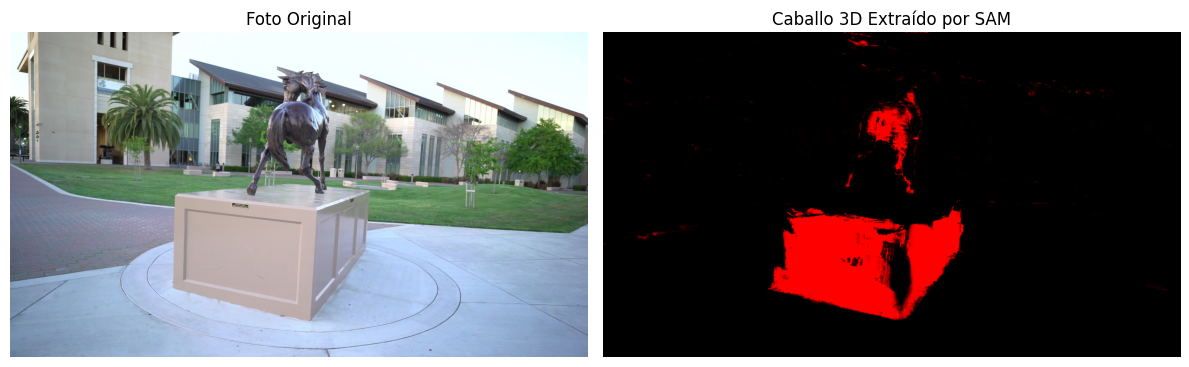

In [7]:
# Tomamos una cámara aleatoria para ver el resultado
test_cam = tr_cams[len(tr_cams)//2]

with torch.no_grad():
    # Renderizamos la escena filtrada
    render_mask = voxel_model.render(test_cam)['color']

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax[0].imshow(im_tensor2np(test_cam.image))
ax[0].set_title("Foto Original")
ax[0].axis('off')

ax[1].imshow(im_tensor2np(render_mask))
ax[1].set_title("Caballo 3D Extraído por SAM")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Si el resultado en la imagen anterior te gustó, guárdalo para el visor web
SEMANTIC_OUTPUT = os.path.join(PROJECT_ROOT, 'results', 'Horse_SAM_Extracted')
os.makedirs(SEMANTIC_OUTPUT, exist_ok=True)

# Restaurar el color real del caballo (para que no sea rojo brillante), pero manteniendo el fondo invisible
with torch.no_grad():
    voxel_model.sh0.data[:] = ori_sh0
    voxel_model.shs.data[:] = ori_shs

print(f"Guardando modelo limpio en: {SEMANTIC_OUTPUT}...")
voxel_model.save_iteration(SEMANTIC_OUTPUT, iteration=99999)

# Recuerda copiar el config.yaml en tu terminal:
# cp results/Horse/config.yaml results/Horse_SAM_Extracted/
# python viz.py results/Horse_SAM_Extracted/

Guardando modelo limpio en: /home/felix/Projects/svraster/results/Horse_SAM_Extracted...


In [ ]:
# --- Celda 1: Configuración inicial ---
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

PROJECT_ROOT = os.path.abspath('../')
sys.path.insert(0, PROJECT_ROOT)

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.utils.image_utils import im_tensor2np
from src.utils.octree_utils import level_2_vox_size
from src.utils.fuser_utils import Fuser

DATA_ROOT = os.path.join(PROJECT_ROOT, 'data', 'Horse')
OUTPUT_ROOT = os.path.join(PROJECT_ROOT, 'results', 'Horse')

# --- Celda 2: Cargar SAM (Segment Anything) ---
from transformers import SamModel, SamProcessor
print("Cargando SAM...")
model_name = "facebook/sam-vit-base"
processor = SamProcessor.from_pretrained(model_name)
sam_model = SamModel.from_pretrained(model_name).to("cuda")
sam_model.eval()

# --- Celda 3: Cargar SVRaster ---
data_pack = DataPack(DATA_ROOT)
tr_cams = data_pack.get_train_cameras()
voxel_model = SparseVoxelModel()
voxel_model.load_iteration(OUTPUT_ROOT)

ori_sh0 = voxel_model.sh0.data.clone()
ori_shs = voxel_model.shs.data.clone()
print(f"Modelo 3D listo: {voxel_model.num_voxels} vóxeles.")

# --- Celda 4: Fusión Geométrico-Semántica ---
with torch.no_grad():
    finest_vox_size = level_2_vox_size(voxel_model.scene_extent, voxel_model.octlevel.max()).item()
    
    # feat_dim=2 (0=Fondo, 1=Objeto) para ahorrar VRAM
    feat_volume = Fuser(xyz=voxel_model.vox_center, bandwidth=50 * finest_vox_size, 
                        feat_dim=2, use_half=True)

    for cam in tqdm(tr_cams[::5], desc="Proyectando Máscaras SAM"):
        img_np = (im_tensor2np(cam.image) * 255).astype(np.uint8)
        H, W = img_np.shape[:2]
        
        # Prompt en el centro de la imagen (ajusta a tus necesidades)
        input_points = [[[W // 2, H // 2]]]
        
        inputs = processor(img_np, input_points=input_points, return_tensors="pt").to("cuda")
        outputs = sam_model(**inputs)
        masks = processor.image_processor.post_process_masks(
            outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), 
            inputs["reshaped_input_sizes"].cpu()
        )
        
        best_mask = masks[0][0][0].float().cuda()
        probs = torch.stack([1.0 - best_mask, best_mask], dim=0)
        
        render_pkg = voxel_model.render(cam, output_depth=True)
        depth = render_pkg['depth'][2]
        feat_volume.integrate(cam=cam, feat=probs, depth=depth)
        
        torch.cuda.empty_cache()

feature = feat_volume.feature.nan_to_num_()
del feat_volume
torch.cuda.empty_cache()

# --- (Celdas 1-4: Igual que antes) ---

# --- Celda 5: Aislamiento Permanente y Guardado ---
from src.utils.activation_utils import rgb2shzero
with torch.no_grad():
    # 1. Definir umbral estricto: El vóxel debe haber sido detectado 
    # como 'caballo' con alta confianza (probabilidad > 0.5)
    horse_probs = feature[..., 1]
    horse_mask = (horse_probs > 0.5) 
    
    print(f"Vóxeles detectados como caballo: {horse_mask.sum().item()}")

    # 2. Hacer invisible el fondo de forma permanente
    # Al establecer la visibilidad (o un factor de escala) a 0 en el Octree
    # logramos que el visor web no renderice esos vóxeles.
    # Nota: Si el visor web sigue mostrando todo, es porque los vóxeles 
    # siguen ahí. Vamos a forzar el color negro absoluto al fondo.
    
    bg_mask = ~horse_mask
    voxel_model.shs.data[bg_mask] = 0.0
    voxel_model.sh0.data[bg_mask] = rgb2shzero(torch.tensor([0.0, 0.0, 0.0], device='cuda'))

    # 3. MANTENER el rojo (o tus colores reales) SOLO en el caballo
    # Si quieres ver los colores reales, usa: voxel_model.sh0.data[horse_mask] = ori_sh0[horse_mask]
    voxel_model.sh0.data[horse_mask] = rgb2shzero(torch.tensor([1.0, 0.0, 0.0], device='cuda'))
    voxel_model.shs.data[horse_mask] = 0.0

    # 4. GUARDAR DIRECTAMENTE AHORA (sin restaurar colores)
    SEMANTIC_OUTPUT = os.path.join(PROJECT_ROOT, 'results', 'Horse_SAM_Extracted')
    os.makedirs(SEMANTIC_OUTPUT, exist_ok=True)
    
    voxel_model.save_iteration(SEMANTIC_OUTPUT, iteration=99999)
    print(f"Modelo guardado exitosamente en {SEMANTIC_OUTPUT}")

Cargando SAM...
